# Titanic 旅客生存概率预测

## 任务：二分类——预测乘客是否生存
## 架构：MLP深度型（4层+BN+Dropout） + MLP宽型（3层大隐藏层）
## 目标精度：≥70%


In [1]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, pandas as pd, os, sys
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

# Auto-detect project root
def get_project_root():
    current = os.path.abspath(os.getcwd())
    for _ in range(5):
        if os.path.exists(os.path.join(current, 'backend')) and os.path.exists(os.path.join(current, 'dataset')):
            return current
        parent = os.path.dirname(current)
        if parent == current: break
        current = parent
    return os.getcwd()
ROOT = get_project_root()
print(f'Project root: {ROOT}')

sys.path.insert(0, os.path.join(ROOT, 'backend', 'titanic_model'))
from model import get_model

import warnings as _w; _w.filterwarnings('ignore', category=UserWarning)
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Project root: C:\Users\DOVE\python学习\大二下实训
Device: cuda


数据形状: (891, 15)
列名: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

缺失值:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

生存率: 38.4%


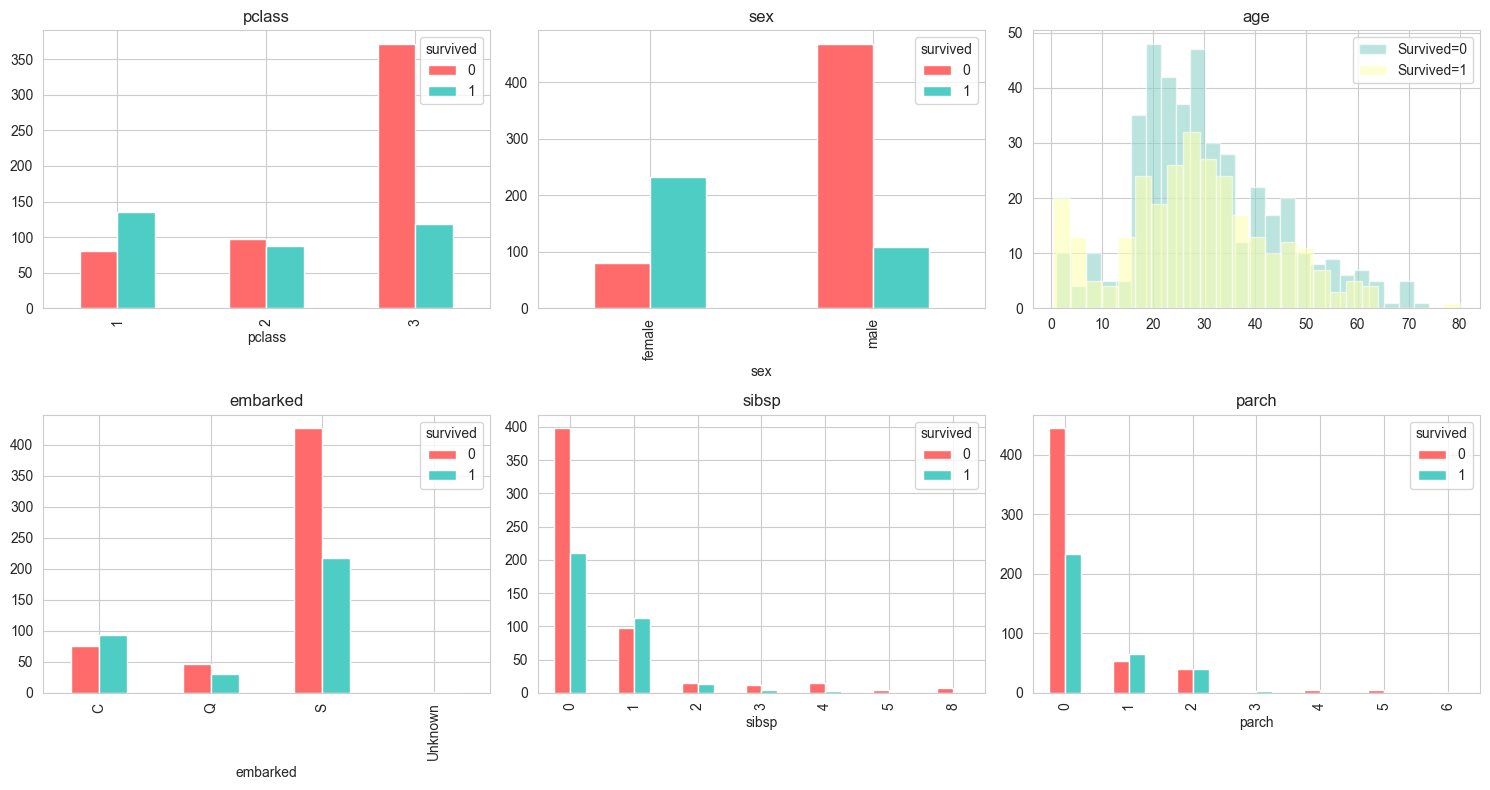

In [2]:
# ==================== 1. 数据加载与探索 ====================
import seaborn as sns_lib
df = sns_lib.load_dataset('titanic')
print(f'数据形状: {df.shape}')
print(f'列名: {list(df.columns)}')
print(f'\n缺失值:\n{df.isnull().sum()}')
print(f'\n生存率: {df.survived.mean()*100:.1f}%')

# 可视化：各类别分布
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['pclass','sex','age','embarked','sibsp','parch']
for ax, feat in zip(axes.flat, features):
    if feat in ['age','fare']:
        for survived in [0,1]:
            subset = df[df.survived==survived][feat].dropna()
            ax.hist(subset, alpha=0.6, label=f'Survived={survived}', bins=25)
        ax.legend()
    else:
        ct = pd.crosstab(df[feat].fillna('Unknown'), df.survived)
        ct.plot(kind='bar', ax=ax, color=['#FF6B6B','#4ECDC4'])
    ax.set_title(feat)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'titanic_model', 'checkpoints', '01_eda.png'), dpi=150, bbox_inches='tight')
plt.show()


In [3]:
# ==================== 2. 特征工程 ====================
df2 = df[['pclass','sex','age','sibsp','parch','fare','embarked','survived']].copy()
df2['sex'] = df2['sex'].map({'male':0,'female':1})
df2['embarked'] = df2['embarked'].map({'C':0,'Q':1,'S':2})
df2['age'] = df2['age'].fillna(df2['age'].median())
df2['fare'] = df2['fare'].fillna(df2['fare'].median())
df2['embarked'] = df2['embarked'].fillna(2)
df2['family_size'] = df2['sibsp'] + df2['parch'] + 1
df2['is_alone'] = (df2['family_size']==1).astype(int)

FEATURES = ['pclass','sex','age','sibsp','parch','fare','embarked','family_size','is_alone']
X = df2[FEATURES].values.astype(np.float32); y = df2['survived'].values.astype(np.float32)

scaler = StandardScaler(); X = scaler.fit_transform(X)
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_v, X_te, y_v, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)
print(f'Train: {len(X_tr)} | Val: {len(X_v)} | Test: {len(X_te)}')

BATCH = 32
tr_loader = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr).unsqueeze(1)), BATCH, True)
v_loader  = DataLoader(TensorDataset(torch.tensor(X_v), torch.tensor(y_v).unsqueeze(1)), BATCH, False)
te_loader  = DataLoader(TensorDataset(torch.tensor(X_te), torch.tensor(y_te).unsqueeze(1)), BATCH, False)


Train: 623 | Val: 134 | Test: 134


In [4]:
# ==================== 3. 训练函数 ====================
def train_epoch_t(model, loader, crit, opt, dev):
    model.train(); loss_sum, correct, total = 0, 0, 0
    for x,y in loader:
        x,y=x.to(dev),y.to(dev); opt.zero_grad()
        loss=crit(model(x),y); loss.backward(); opt.step()
        loss_sum+=loss.item(); preds=(model(x)>0.5).float()
        correct+=preds.eq(y).sum().item(); total+=y.size(0)
    return loss_sum/len(loader), correct/total

@torch.no_grad()
def evaluate_t(model, loader, crit, dev):
    model.eval(); loss_sum, correct, total = 0, 0, 0
    all_probs, all_labels = [], []
    for x,y in loader:
        x,y=x.to(dev),y.to(dev); out=model(x)
        loss_sum+=crit(out,y).item(); preds=(out>0.5).float()
        correct+=preds.eq(y).sum().item(); total+=y.size(0)
        all_probs.extend(out.cpu().numpy().flatten()); all_labels.extend(y.cpu().numpy().flatten())
    return loss_sum/len(loader), correct/total, all_probs, all_labels

def train_titanic(model, name, tr_loader, v_loader, epochs, patience, dev):
    model=model.to(dev); crit=nn.BCELoss(); opt=optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    sched=optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=10, factor=0.5)
    hist={'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[]}
    best_acc, best_st, wait=0, None, 0
    for ep in range(epochs):
        tl,ta=train_epoch_t(model,tr_loader,crit,opt,dev)
        vl,va,_,_=evaluate_t(model,v_loader,crit,dev); sched.step(vl)
        for k,v in zip(['train_loss','train_acc','val_loss','val_acc'],[tl,ta,vl,va]): hist[k].append(v)
        if (ep+1)%20==0: print(f'[{name}] E{ep+1:3d} | TA={ta:.4f} | VA={va:.4f}')
        if va>best_acc: best_acc=va; best_st={k:v.cpu().clone() for k,v in model.state_dict().items()}; wait=0
        else: wait+=1
        if wait>=patience: print(f'Early stop at {ep+1}'); break
    model.load_state_dict(best_st)
    return model, hist, best_acc


In [5]:
# ==================== 4. 训练 MLP 深度型 ====================
print('=== MLP Deep (4层+BN) ===')
mlp_deep = get_model('mlp', X.shape[1])
mlp_deep, hist_deep, acc_deep = train_titanic(mlp_deep, 'MLP-Deep', tr_loader, v_loader, 200, 30, DEVICE)
_, te_acc_deep, probs_deep, labels_deep = evaluate_t(mlp_deep, te_loader, nn.BCELoss(), DEVICE)
print(f'MLP-Deep Test Acc: {te_acc_deep:.4f}')


=== MLP Deep (4层+BN) ===
[MLP-Deep] E 20 | TA=0.8266 | VA=0.8657
[MLP-Deep] E 40 | TA=0.8266 | VA=0.8433
Early stop at 48
MLP-Deep Test Acc: 0.7537


In [6]:
# ==================== 5. 训练 MLP 宽型 ====================
print('=== MLP Wide (3层宽网络) ===')
mlp_wide = get_model('mlp_wide', X.shape[1])
mlp_wide, hist_wide, acc_wide = train_titanic(mlp_wide, 'MLP-Wide', tr_loader, v_loader, 200, 30, DEVICE)
_, te_acc_wide, probs_wide, labels_wide = evaluate_t(mlp_wide, te_loader, nn.BCELoss(), DEVICE)
print(f'MLP-Wide Test Acc: {te_acc_wide:.4f}')


=== MLP Wide (3层宽网络) ===
[MLP-Wide] E 20 | TA=0.8411 | VA=0.8433
Early stop at 32
MLP-Wide Test Acc: 0.7612


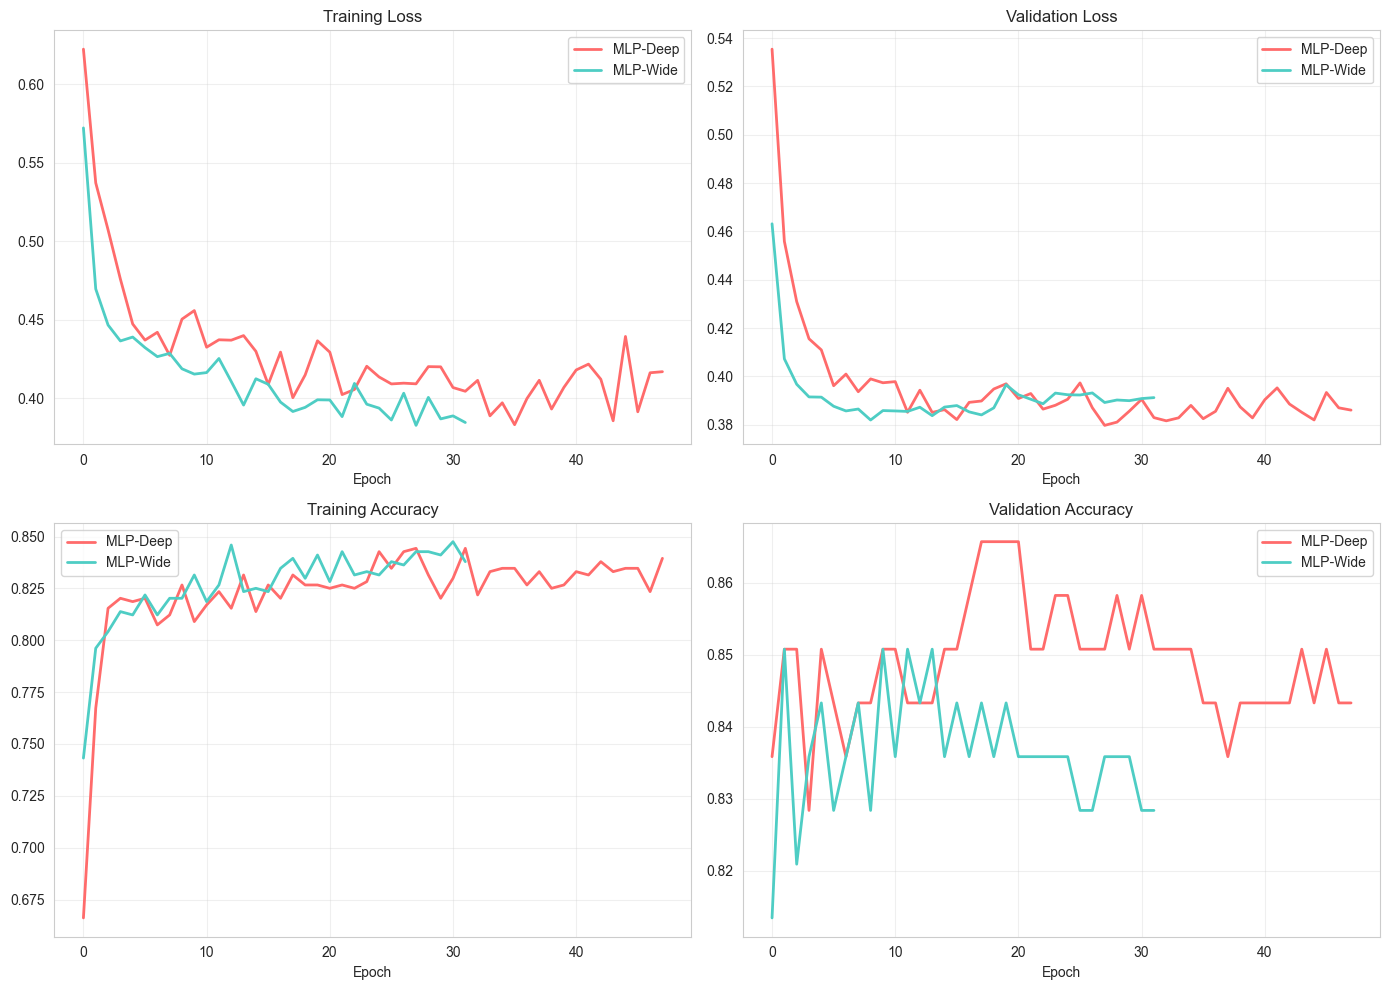

In [7]:
# ==================== 6. 训练曲线对比 ====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, key, title in [(axes[0,0],'train_loss','Training Loss'), (axes[0,1],'val_loss','Validation Loss'),
                        (axes[1,0],'train_acc','Training Accuracy'), (axes[1,1],'val_acc','Validation Accuracy')]:
    ax.plot(hist_deep[key], label='MLP-Deep', color='#FF6B6B', linewidth=2)
    ax.plot(hist_wide[key], label='MLP-Wide', color='#4ECDC4', linewidth=2)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'titanic_model', 'checkpoints', '02_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


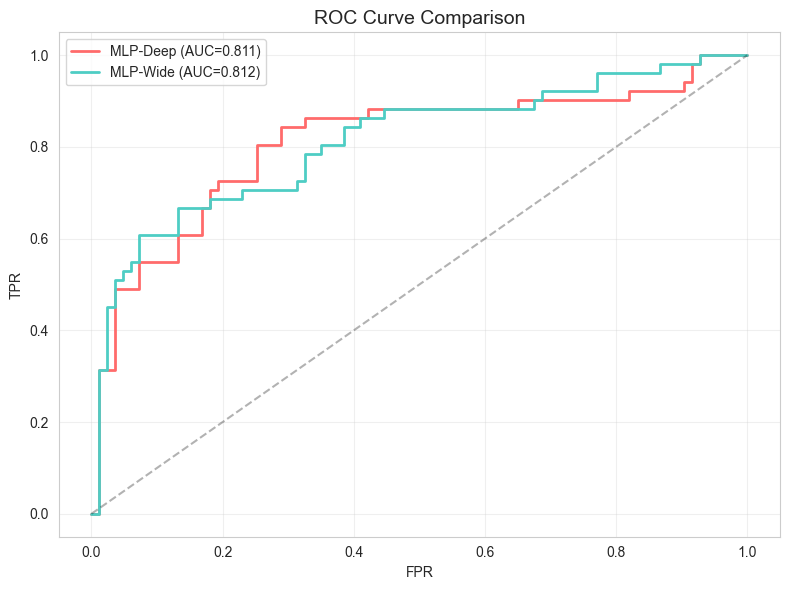

In [8]:
# ==================== 7. ROC曲线对比 ====================
fig, ax = plt.subplots(figsize=(8, 6))
for probs, labels, name, color in [(probs_deep, labels_deep, 'MLP-Deep', '#FF6B6B'),
                                     (probs_wide, labels_wide, 'MLP-Wide', '#4ECDC4')]:
    fpr, tpr, _ = roc_curve(labels, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.3f})', color=color, linewidth=2)
ax.plot([0,1],[0,1],'k--',alpha=0.3); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve Comparison', fontsize=14); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'titanic_model', 'checkpoints', '03_roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


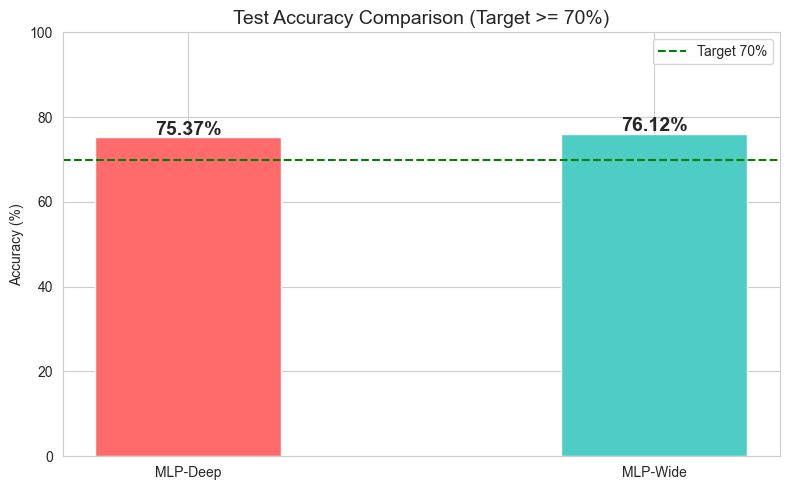

Saved. MLP-Deep: 75.4% | MLP-Wide: 76.1%


In [9]:
# ==================== 8. 模型对比与保存 ====================
fig, ax = plt.subplots(figsize=(8, 5))
models = ['MLP-Deep', 'MLP-Wide']
accs = [te_acc_deep*100, te_acc_wide*100]
bars = ax.bar(models, accs, color=['#FF6B6B','#4ECDC4'], edgecolor='white', width=0.4)
for b, v in zip(bars, accs): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=14)
ax.set_ylabel('Accuracy (%)'); ax.set_title('Test Accuracy Comparison (Target >= 70%)', fontsize=14)
ax.axhline(y=70, color='green', linestyle='--', label='Target 70%'); ax.legend(); ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'titanic_model', 'checkpoints', '04_accuracy_compare.png'), dpi=150, bbox_inches='tight')
plt.show()

# 保存
CKPT = os.path.join(ROOT, 'backend', 'titanic_model', 'checkpoints')
torch.save({
    'mlp_state_dict': {k:v.cpu().clone() for k,v in mlp_deep.state_dict().items()},
    'mlp_wide_state_dict': {k:v.cpu().clone() for k,v in mlp_wide.state_dict().items()},
    'input_dim': X.shape[1], 'feature_cols': FEATURES,
    'test_accuracy_mlp': te_acc_deep, 'test_accuracy_mlp_wide': te_acc_wide,
    'scaler_mean': scaler.mean_.tolist(), 'scaler_scale': scaler.scale_.tolist(),
}, os.path.join(CKPT, 'best_model.pth'))
print(f'Saved. MLP-Deep: {te_acc_deep*100:.1f}% | MLP-Wide: {te_acc_wide*100:.1f}%')
